In [16]:
# иморитирование всех необходимых библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [17]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [19]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


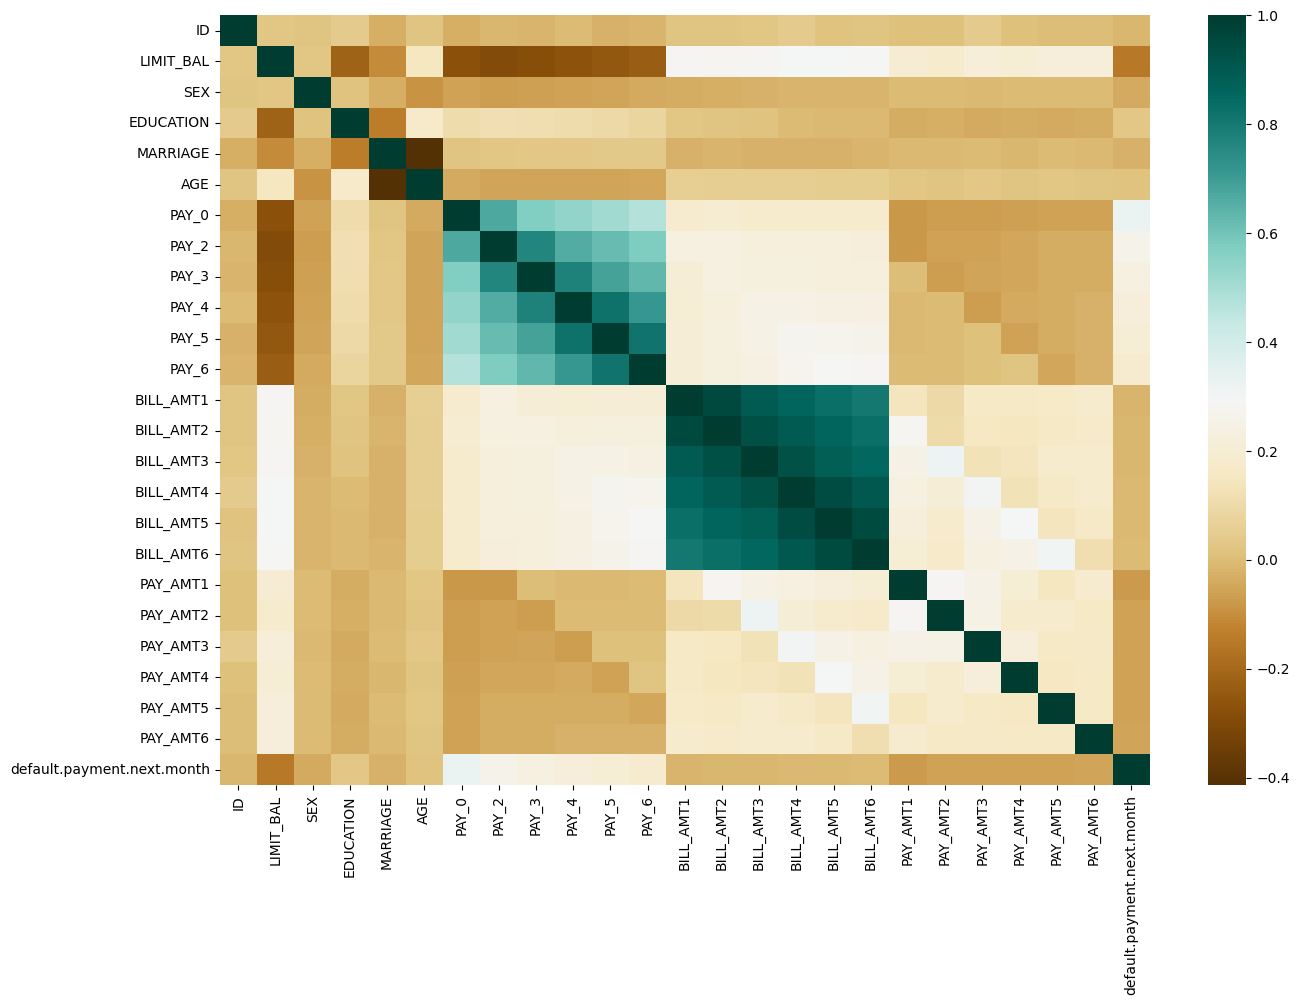

In [20]:
import seaborn as sns
import numpy as np

df_corr = df.corr()

f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(df_corr, mask=np.zeros_like(df_corr, dtype=np.bool), cmap = "BrBG",ax=ax)
plt.show()

In [21]:
X = df.drop(['default.payment.next.month','ID'], axis=1)  # delete target & ID
y = df['default.payment.next.month']  # Целевой признак



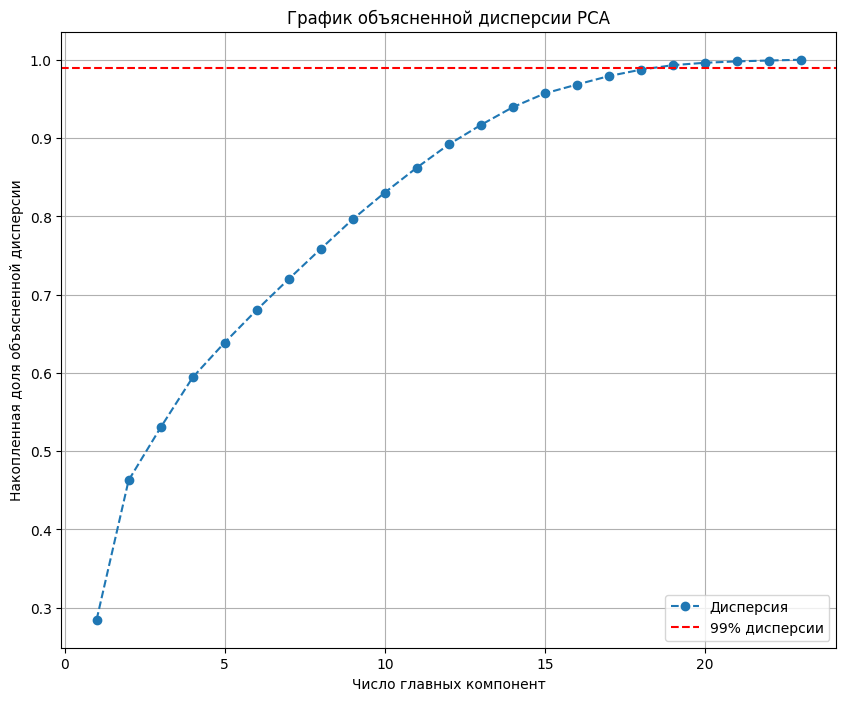

In [22]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)


plt.figure(figsize=(10, 8))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label="Дисперсия")

# Добавляем горизонтальную линию на уровне 0.9
plt.axhline(y=0.99, color='r', linestyle='--', label="99% дисперсии")


plt.xlabel('Число главных компонент')
plt.ylabel('Накопленная доля объясненной дисперсии')
plt.title('График объясненной дисперсии PCA')
plt.legend()
plt.grid()
plt.show()

In [23]:
components = pca.components_  # Отобранные компоненты

components_df = pd.DataFrame(pca.components_, columns=X.columns)

# Печать таблицы значений компонент
print("Значения компонент PCA:")
components_df



Значения компонент PCA:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,0.068518,-0.021656,0.019206,-0.005600,0.014232,0.161082,0.194120,0.200213,0.207038,0.210960,...,0.349777,0.353883,0.351752,0.344514,0.094231,0.078681,0.086394,0.077793,0.075354,0.069948
1,-0.316323,-0.030595,0.091523,0.043251,-0.066578,0.298124,0.334821,0.343894,0.344581,0.331600,...,-0.146213,-0.145450,-0.143761,-0.141872,-0.149109,-0.139872,-0.151570,-0.141409,-0.137191,-0.129396
2,-0.017454,-0.024038,0.316426,-0.453185,0.462347,0.017508,-0.017774,-0.061731,-0.088930,-0.108708,...,0.083916,0.070509,0.056569,0.047549,-0.281865,-0.301835,-0.280300,-0.237382,-0.194267,-0.209305
3,0.069984,-0.078230,0.246585,-0.444561,0.462753,0.015959,0.049868,0.084273,0.109367,0.115576,...,-0.104789,-0.100610,-0.088744,-0.084063,0.280361,0.310998,0.278231,0.236485,0.176168,0.207186
4,-0.149540,0.884073,0.364899,-0.053334,-0.163912,-0.034525,-0.037050,-0.023652,-0.007809,0.001694,...,0.029860,0.022572,0.022349,0.010474,0.092720,0.107915,0.036236,0.013948,-0.056760,-0.051711
5,-0.375676,-0.395388,0.565257,0.279548,-0.088952,-0.039892,-0.061115,-0.070125,-0.087238,-0.086859,...,0.085403,0.064150,0.024996,-0.021460,0.238523,0.255934,0.142904,-0.060213,-0.253200,-0.192006
6,-0.106110,-0.065094,0.399833,0.159849,-0.081346,0.086633,0.091957,0.020881,-0.039214,-0.103803,...,0.003353,-0.065913,-0.080166,0.049603,-0.202909,-0.104132,-0.227246,-0.023995,0.701664,0.360803
7,-0.059293,-0.027696,0.080926,0.026321,-0.012932,0.021382,0.015629,-0.026540,-0.056173,-0.033868,...,-0.125911,-0.036857,0.113132,0.163329,-0.267225,-0.219072,0.230156,0.646597,0.197161,-0.536736
8,-0.021453,-0.018997,0.154520,0.055692,-0.046764,0.030427,0.033381,0.011380,-0.044287,-0.054338,...,-0.079662,-0.026672,0.069435,-0.080792,-0.036307,-0.393352,0.033554,0.445782,-0.475222,0.597104
9,0.017481,0.024262,0.062895,0.038577,0.007894,0.002958,0.006325,-0.024867,-0.056812,0.066969,...,-0.122243,0.123538,-0.005505,0.013795,-0.236318,-0.278951,0.784744,-0.435286,0.056239,0.104764


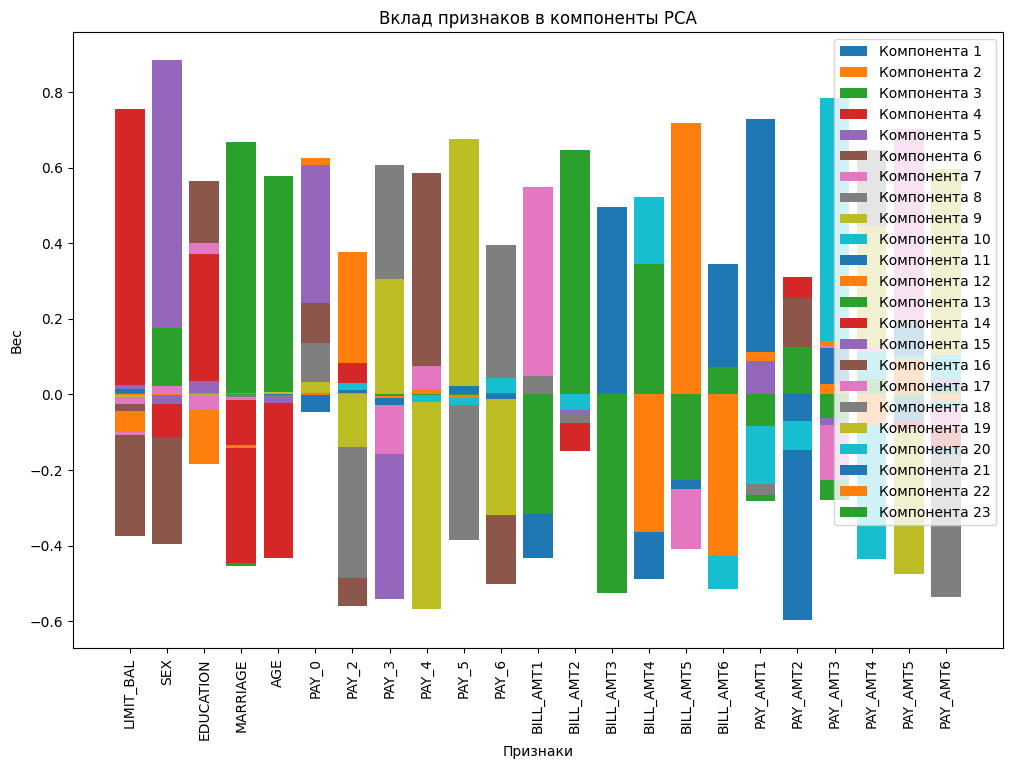

In [10]:
plt.figure(figsize=(12, 8))
for i in range(components_df.shape[0]):
    plt.bar(range(len(X.columns)), components_df.iloc[i, :], label=f'Компонента {i+1}')

plt.title('Вклад признаков в компоненты PCA')
plt.xlabel('Признаки')
plt.ylabel('Вес')
plt.xticks(range(len(X.columns)), X.columns, rotation=90)
plt.legend()
plt.show()

In [24]:
from sklearn.linear_model import Lasso

# Обучение Lasso Regression
model = Lasso(alpha=0.1)
model.fit(X, y)

# Отбор признаков
coef = pd.Series(model.coef_, index=X.columns)
print(coef[coef != 0])  # Важные признаки

LIMIT_BAL   -3.982872e-07
AGE          4.376781e-04
PAY_0        2.261948e-02
BILL_AMT1   -5.850306e-07
BILL_AMT2    3.681694e-07
BILL_AMT3    4.287908e-08
BILL_AMT4   -1.894922e-08
BILL_AMT5    1.953407e-07
BILL_AMT6    3.325020e-07
PAY_AMT1    -1.180525e-06
PAY_AMT2    -3.309144e-07
PAY_AMT3    -2.911090e-07
PAY_AMT4    -5.908361e-07
PAY_AMT5    -5.539852e-07
PAY_AMT6    -1.277448e-07
dtype: float64


In [25]:
# Создание нового датасета с отобранными признаками
# Определение отобранных признаков (с ненулевыми коэффициентами)
selected_features = coef[coef != 0].index.tolist()
X_selected = X[selected_features]

# Проверка результата
print("Отобранные признаки:", selected_features)
print("Новый датасет с отобранными признаками:\n", X_selected)

Отобранные признаки: ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Новый датасет с отобранными признаками:
        LIMIT_BAL  AGE  PAY_0  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  \
0        20000.0   24      2     3913.0     3102.0      689.0        0.0   
1       120000.0   26     -1     2682.0     1725.0     2682.0     3272.0   
2        90000.0   34      0    29239.0    14027.0    13559.0    14331.0   
3        50000.0   37      0    46990.0    48233.0    49291.0    28314.0   
4        50000.0   57     -1     8617.0     5670.0    35835.0    20940.0   
...          ...  ...    ...        ...        ...        ...        ...   
29995   220000.0   39      0   188948.0   192815.0   208365.0    88004.0   
29996   150000.0   43     -1     1683.0     1828.0     3502.0     8979.0   
29997    30000.0   37      4     3565.0     3356.0     2758.0    20878.0  

In [55]:
# Сохранение DataFrame в CSV файл
X_selected.to_csv('dataset.csv', index=False) 

In [26]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)  # Разделение на выборки
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [27]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
y_pred = model.predict(X_test)

# Отчет о классификации
print(classification_report(y_test, y_pred))

# Матрица путаницы
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.63      0.35      0.45      1313

    accuracy                           0.81      6000
   macro avg       0.73      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

[[4422  265]
 [ 858  455]]


In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   7.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   7.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   7.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   7.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   6.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   7.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   7.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   7.9s
[CV] END m

In [29]:

y_pred_best = best_model.predict(X_test)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)  # Разделение на выборки
accuracy = accuracy_score(y_test, y_pred_best)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.82


In [31]:
# Получение лучших гиперпараметров
best_params = grid_search.best_params_
print("Best Model Parameters:", best_params)
y_pred_best

Best Model Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


array([0, 0, 0, ..., 0, 0, 0], shape=(6000,))

Подбор гиперпараметров через RandomizedSearchCV

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [33]:
param_distributions = {
    'n_estimators': randint(100, 300),         # Число деревьев от 50 до 300
    'max_depth': [None] + list(range(10, 40)),  # Глубина деревьев (от 10 до 50)
    'min_samples_split': randint(2, 20),      # Минимальное количество образцов для разделения
    'min_samples_leaf': randint(1, 20),       # Минимальное количество образцов на листовом узле
    'max_features': ['auto', 'sqrt', 'log2']  # Количество признаков для выбора
}


In [34]:
# Начальная модель
rf = RandomForestClassifier(random_state=42)

# RandomizedSearchCV: 10 итераций (можно увеличить для более точного поиска)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=10,  # Количество итераций
    cv=3,       # Число фолдов кросс-валидации
    verbose=2,
    random_state=42,
    n_jobs=-1   # Использовать все доступные ядра
)

In [35]:
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


[CV] END max_depth=15, max_features=auto, min_samples_leaf=15, min_samples_split=12, n_estimators=171; total time=   0.0s
[CV] END max_depth=37, max_features=auto, min_samples_leaf=7, min_samples_split=12, n_estimators=187; total time=   0.0s
[CV] END max_depth=28, max_features=auto, min_samples_leaf=3, min_samples_split=6, n_estimators=150; total time=   0.0s
[CV] END max_depth=37, max_features=auto, min_samples_leaf=7, min_samples_split=12, n_estimators=187; total time=   0.0s
[CV] END max_depth=28, max_features=auto, min_samples_leaf=3, min_samples_split=6, n_estimators=150; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_leaf=9, min_samples_split=8, n_estimators=117; total time=   0.0s
[CV] END max_depth=15, max_features=auto, min_samples_leaf=9, min_samples_split=8, n_estimators=117; total time=   0.0s
[CV] END max_depth=37, max_features=auto, min_samples_leaf=7, min_samples_split=12, n_estimators=187; total time=   0.0s
[CV] END max_depth=15, max_features

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': <scipy.stats....x7c5015d0d610>, 'min_samples_split': <scipy.stats....x7c5015e024e0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-v

In [36]:
best_model_RSCV = random_search.best_estimator_
best_params_RSCV = random_search.best_params_

print("Best Parameters:", best_params_RSCV)

Best Parameters: {'max_depth': 38, 'max_features': 'log2', 'min_samples_leaf': 19, 'min_samples_split': 13, 'n_estimators': 154}


In [37]:
y_pred_best_RSCV = best_model_RSCV.predict(X_test)

In [38]:
accuracy2 = accuracy_score(y_test, y_pred_best_RSCV)
print(f'Accuracy: {accuracy2:.2f}')

Accuracy: 0.82


Пробуем модель LogisticRegression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [51]:
X_trainx, X_testx, y_trainx, y_testx = train_test_split(X_selected, y, test_size=0.2, random_state=42)  # Разделение на выборки
model_LR = LogisticRegression(random_state=42)
model_LR.fit(X_trainx, y_trainx)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [52]:
y_pred_LR = model_LR.predict(X_testx)
# Точность
accuracy3 = accuracy_score(y_testx, y_pred_LR)
print(f'Accuracy: {accuracy3:.2f}')

Accuracy: 0.78


Пробуем модель GradientBoostingClassifier

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

In [53]:

model_GB = GradientBoostingClassifier(random_state=42)
model_GB.fit(X_trainx, y_trainx)

y_predGB = model_GB.predict(X_testx)

In [54]:
# Точность
accuracy4 = accuracy_score(y_testx, y_predGB)
print(f'Accuracy: {accuracy4:.2f}')

Accuracy: 0.82


In [46]:
#обучим на всей выборке
scaler = StandardScaler()
X_full = scaler.fit_transform(X_selected)
model_GB.fit(X_full, y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

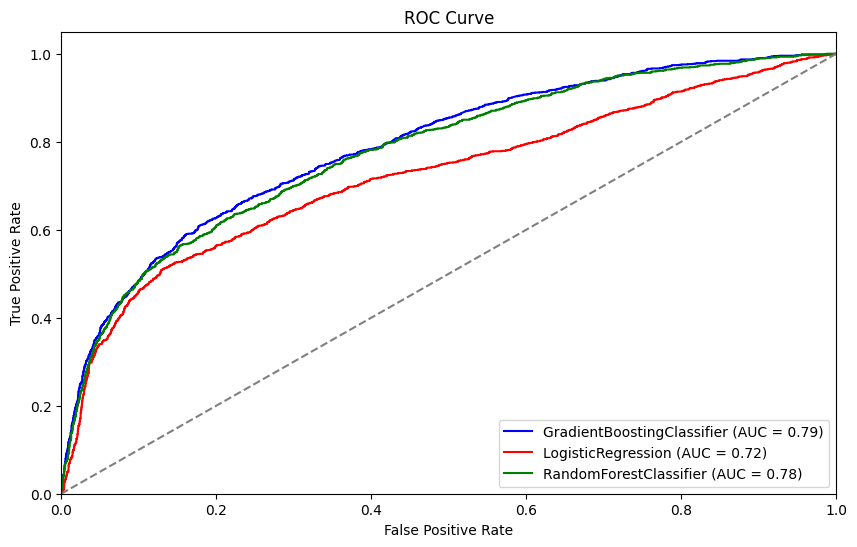

In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Вероятности положительного класса
y_prob_gb = model_GB.predict_proba(X_test)[:, 1]
y_prob_lr = model_LR.predict_proba(X_test)[:, 1]
y_prob_rf = best_model_RSCV.predict_proba(X_test)[:, 1]

# Рассчёт ROC и AUC
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

roc_auc_gb = auc(fpr_gb, tpr_gb)
roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Визуализация ROC-кривых
plt.figure(figsize=(10, 6))
plt.plot(fpr_gb, tpr_gb, color='blue', label='GradientBoostingClassifier (AUC = %0.2f)' % roc_auc_gb)
plt.plot(fpr_lr, tpr_lr, color='red', label='LogisticRegression (AUC = %0.2f)' % roc_auc_lr)
plt.plot(fpr_rf, tpr_rf, color='green', label='RandomForestClassifier (AUC = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print("Кросс-валидация: среднее значение =", scores.mean(), "среднее отклонение =", scores.std())

Кросс-валидация: среднее значение = 0.8205 среднее отклонение = 0.0025365385425373836


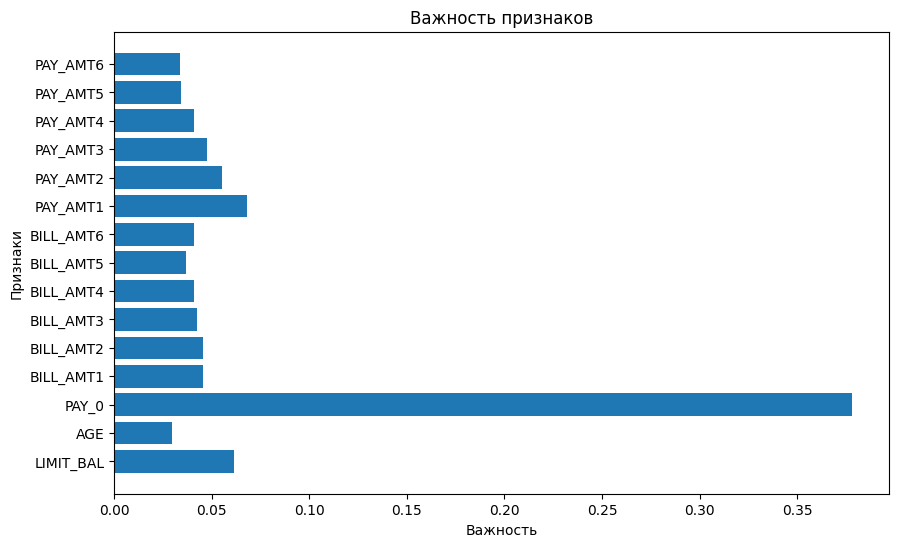

In [49]:
# Получение важности признаков
importances = random_search.best_estimator_.feature_importances_

# Строим график
plt.figure(figsize=(10, 6))
plt.barh(X_selected.columns, importances)
plt.title('Важность признаков')
plt.xlabel('Важность')
plt.ylabel('Признаки')
plt.show()

In [50]:
import joblib

In [89]:
# Сохранение модели
#joblib.dump(model_GB, 'gradient_boosting_model.joblib')
joblib.dump(model_GB, 'GBselect_model.joblib')

['GBselect_model.joblib']